# Olist Brazilian E-Commerce: Customer Intelligence Analysis
**Why 97% of Olist Buyers Never Come Back — and What to Do About It**

Dataset: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
Period: September 2016 – October 2018

In [18]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']      = 130
plt.rcParams['font.size']       = 16
plt.rcParams['axes.titlesize']  = 24
plt.rcParams['figure.titlesize']= 28
plt.rcParams['axes.labelsize']  = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlepad']   = 20

BQ_PROJECT = "dsai-module-2-project-496708"
client = bigquery.Client(project=BQ_PROJECT)

def q(sql):
    return client.query(sql).to_dataframe()

print(f"Connected to BigQuery: {BQ_PROJECT}")

Connected to BigQuery: dsai-module-2-project-496708


---
## 1. Monthly Sales Trends

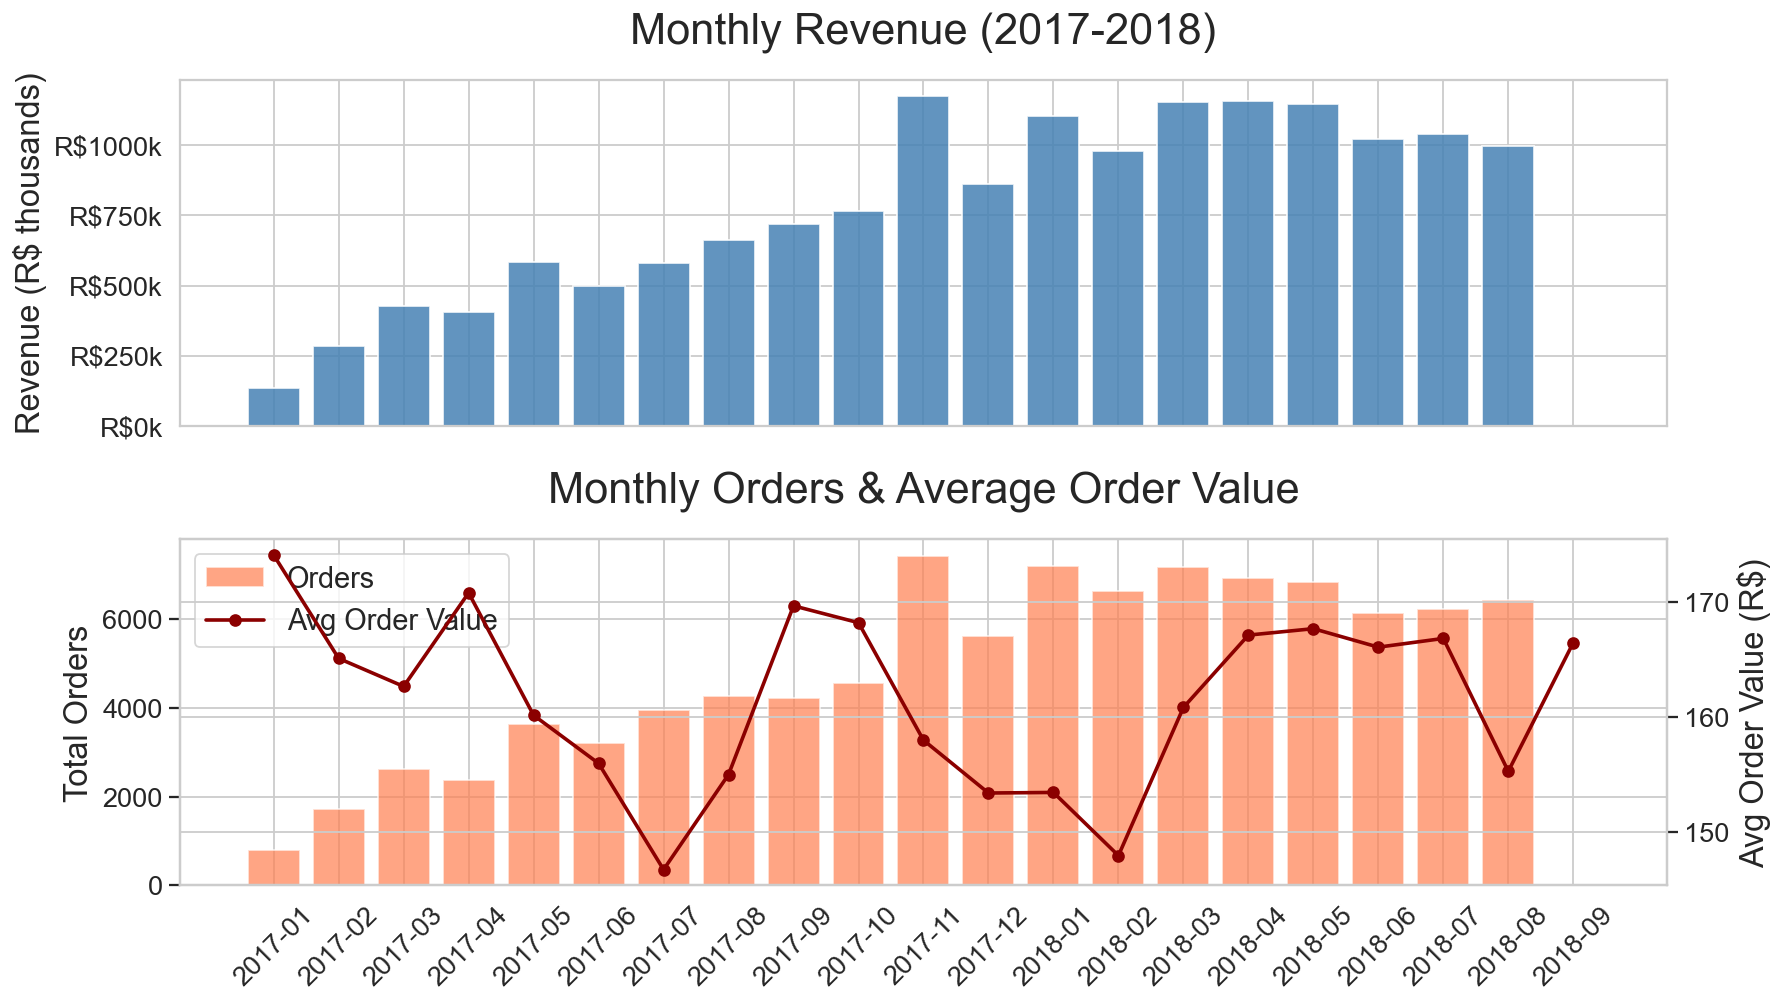

Peak month: 2017-11 — R$1,172,639
Total 2017-2018 revenue: R$15,687,324


In [19]:
monthly = q(f"""
    SELECT * FROM `{BQ_PROJECT}.olist_marts.monthly_sales` ORDER BY month_start
""")

monthly['month_label'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(monthly['month_label'], monthly['total_revenue'] / 1e3, color='steelblue', alpha=0.85)
axes[0].set_ylabel('Revenue (R$ thousands)')
axes[0].set_title('Monthly Revenue (2017-2018)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}k'))

ax2 = axes[1].twinx()
axes[1].bar(monthly['month_label'], monthly['total_orders'], color='coral', alpha=0.7, label='Orders')
ax2.plot(monthly['month_label'], monthly['avg_order_value'], color='darkred', marker='o', linewidth=2, label='Avg Order Value')
axes[1].set_ylabel('Total Orders')
ax2.set_ylabel('Avg Order Value (R$)')
axes[1].set_title('Monthly Orders & Average Order Value')
axes[1].tick_params(axis='x', rotation=45)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../docs/monthly_sales.png', bbox_inches='tight')
plt.show()

print(f"Peak month: {monthly.loc[monthly.total_revenue.idxmax(), 'month_label']} — R${monthly.total_revenue.max():,.0f}")
print(f"Total 2017-2018 revenue: R${monthly.total_revenue.sum():,.0f}")

---
## 2. Customer RFM Segmentation

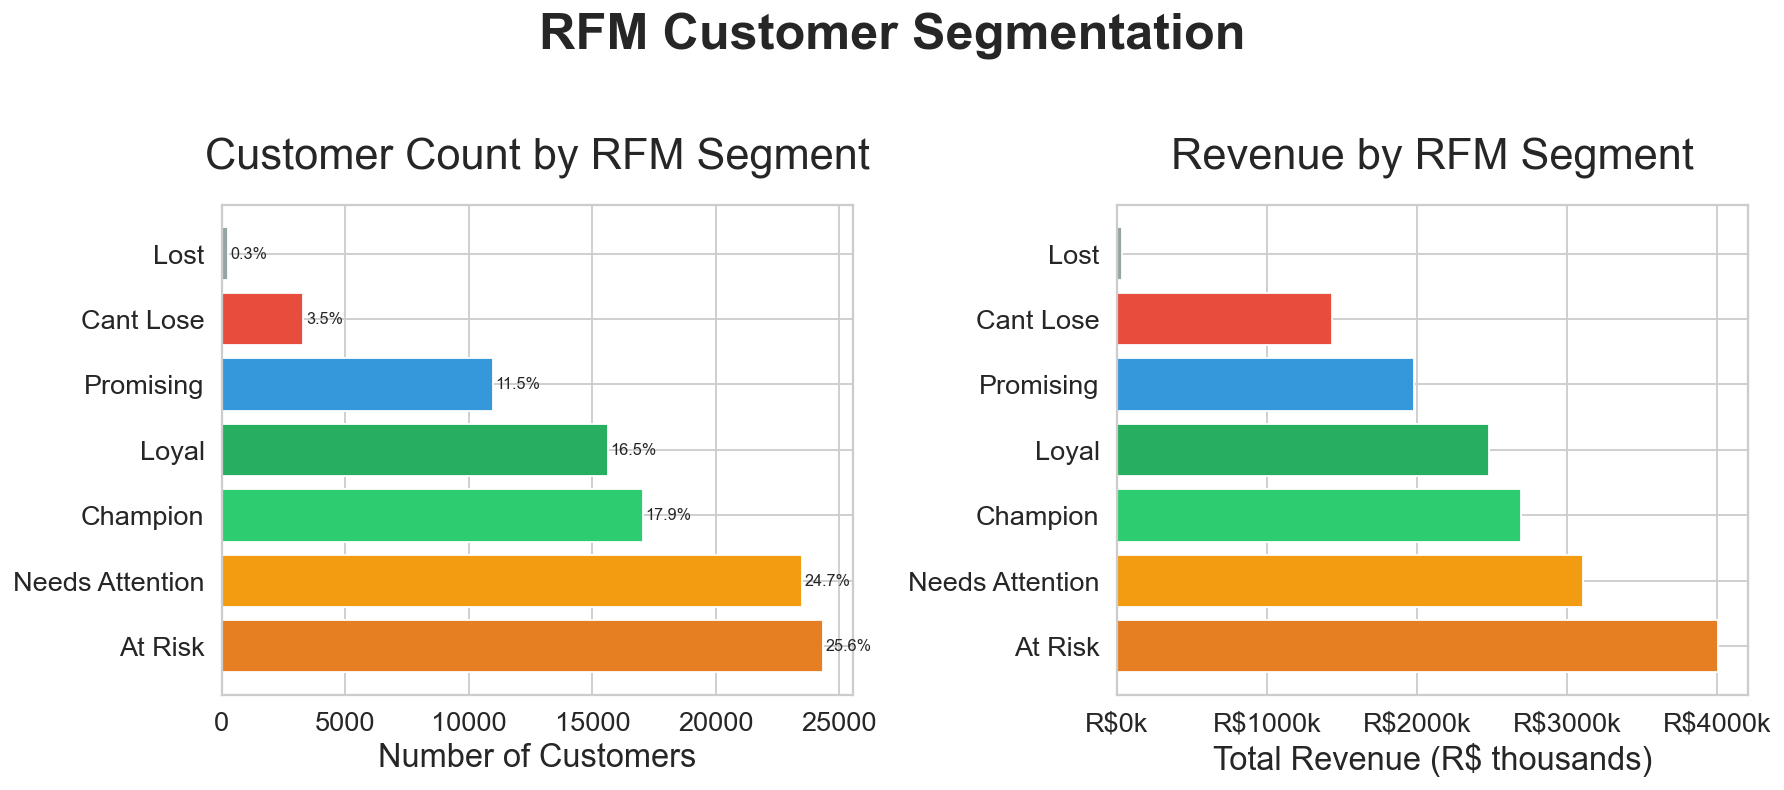

        segment  count       pct  total_revenue
        At Risk  24330 25.613222     4007608.82
Needs Attention  23485 24.723655     3106932.20
       Champion  17034 17.932414     2693926.33
          Loyal  15630 16.454364     2483345.83
      Promising  10960 11.538057     1978778.01
      Cant Lose   3303  3.477208     1435440.61
           Lost    248  0.261080       33105.21


In [20]:
rfm = q(f"SELECT * FROM `{BQ_PROJECT}.olist_marts.customer_rfm`")

seg_counts = rfm['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']
seg_counts['pct'] = 100 * seg_counts['count'] / seg_counts['count'].sum()

seg_revenue = rfm.groupby('segment')['monetary'].sum().reset_index()
seg_revenue.columns = ['segment', 'total_revenue']
seg_summary = seg_counts.merge(seg_revenue, on='segment').sort_values('total_revenue', ascending=False)

SEGMENT_COLORS = {
    'Champion':       '#2ecc71',
    'Loyal':          '#27ae60',
    'Promising':      '#3498db',
    'Needs Attention':'#f39c12',
    'At Risk':        '#e67e22',
    'Cant Lose':      '#e74c3c',
    'Lost':           '#95a5a6',
}
colors = [SEGMENT_COLORS.get(s, '#bdc3c7') for s in seg_summary['segment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(seg_summary['segment'], seg_summary['count'], color=colors)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by RFM Segment')
for i, (count, pct) in enumerate(zip(seg_summary['count'], seg_summary['pct'])):
    axes[0].text(count + 100, i, f'{pct:.1f}%', va='center', fontsize=9)

axes[1].barh(seg_summary['segment'], seg_summary['total_revenue'] / 1e3, color=colors)
axes[1].set_xlabel('Total Revenue (R$ thousands)')
axes[1].set_title('Revenue by RFM Segment')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}k'))

plt.suptitle('RFM Customer Segmentation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/rfm_segments.png', bbox_inches='tight')
plt.show()

print(seg_summary[['segment','count','pct','total_revenue']].to_string(index=False))

In [21]:
# Repeat purchase rate — the headline finding
total = len(rfm)
repeat = (rfm['frequency'] > 1).sum()
repeat_rev = rfm[rfm['frequency'] > 1]['monetary'].sum()
total_rev = rfm['monetary'].sum()

print(f"Total unique customers: {total:,}")
print(f"Repeat buyers (2+ orders): {repeat:,} ({100*repeat/total:.1f}%)")
print(f"Revenue from repeat buyers: R${repeat_rev:,.0f} ({100*repeat_rev/total_rev:.1f}% of total revenue)")
print(f"\nAvg monetary value — one-time: R${rfm[rfm.frequency==1].monetary.mean():.2f}")
print(f"Avg monetary value — repeat:   R${rfm[rfm.frequency>1].monetary.mean():.2f}")

Total unique customers: 94,990
Repeat buyers (2+ orders): 2,888 (3.0%)
Revenue from repeat buyers: R$890,534 (5.7% of total revenue)

Avg monetary value — one-time: R$161.22
Avg monetary value — repeat:   R$308.36


---
## 3. Delivery Performance vs Customer Satisfaction

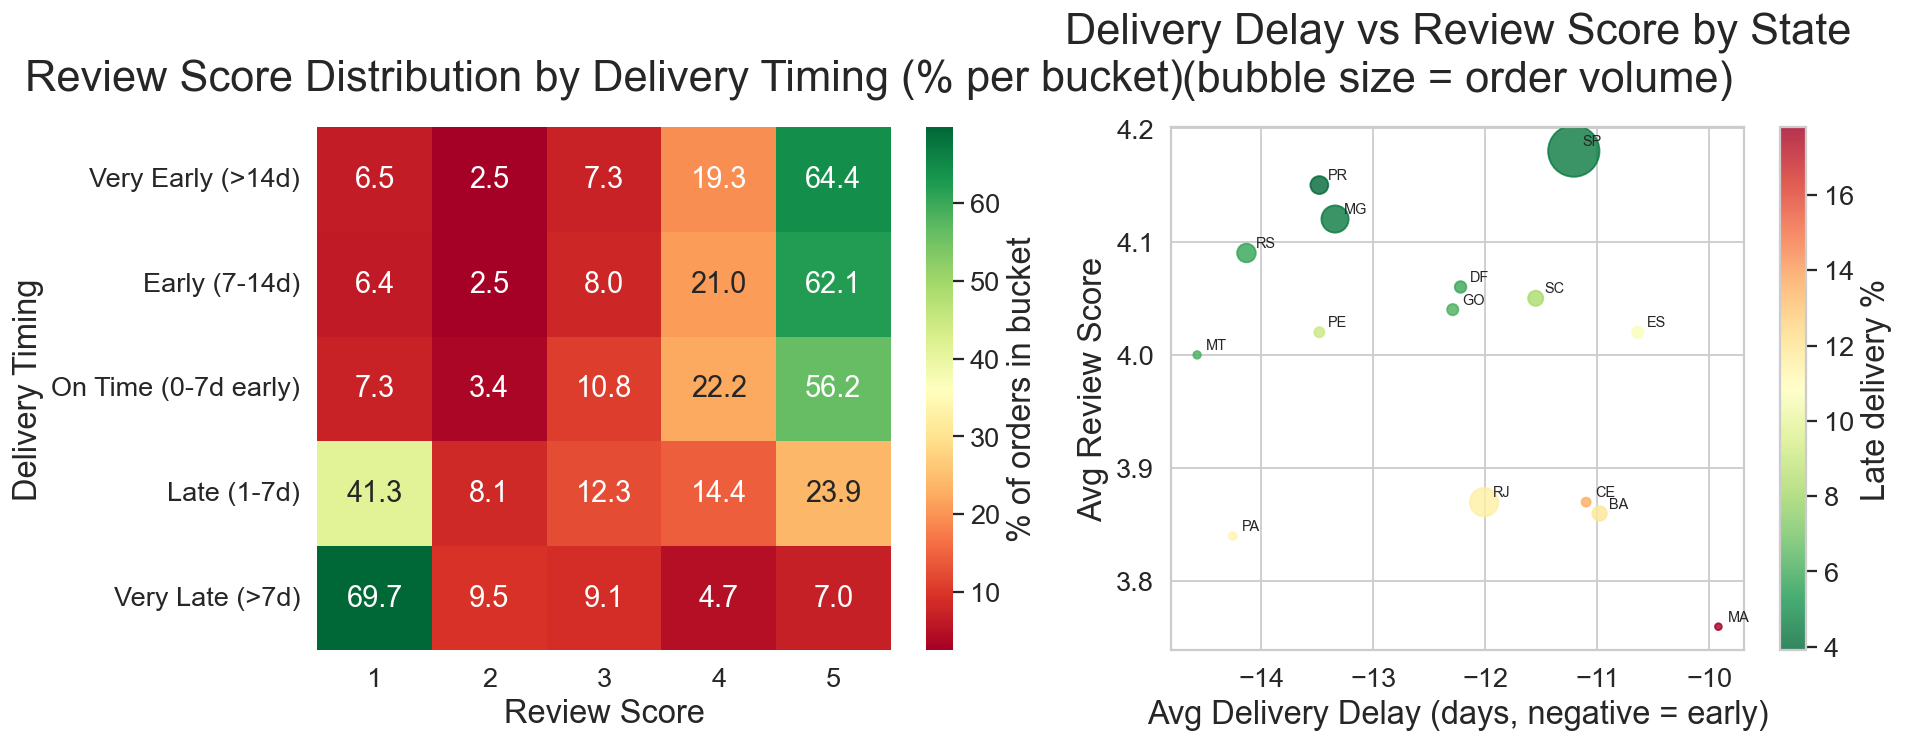

In [22]:
sat = q(f"SELECT * FROM `{BQ_PROJECT}.olist_marts.satisfaction_vs_delivery`")

pivot = sat.pivot(index='delivery_bucket', columns='review_score', values='order_count').fillna(0).astype(float)
bucket_order = ['Very Early (>14d)', 'Early (7-14d)', 'On Time (0-7d early)', 'Late (1-7d)', 'Very Late (>7d)']
pivot = pivot.reindex([b for b in bucket_order if b in pivot.index])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pct_pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pct_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], cbar_kws={'label': '% of orders in bucket'})
axes[0].set_title('Review Score Distribution by Delivery Timing (% per bucket)')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Delivery Timing')

state_del = q(f"""
    SELECT customer_state, avg_review_score, avg_delay_days, total_orders, late_pct
    FROM `{BQ_PROJECT}.olist_marts.delivery_by_state`
    ORDER BY total_orders DESC LIMIT 15
""")

scatter = axes[1].scatter(
    state_del['avg_delay_days'],
    state_del['avg_review_score'],
    s=state_del['total_orders'] / 50,
    c=state_del['late_pct'],
    cmap='RdYlGn_r',
    alpha=0.8
)
for _, row in state_del.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_delay_days'], row['avg_review_score']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
plt.colorbar(scatter, ax=axes[1], label='Late delivery %')
axes[1].set_xlabel('Avg Delivery Delay (days, negative = early)')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Delivery Delay vs Review Score by State\n(bubble size = order volume)')

plt.tight_layout()
plt.savefig('../docs/delivery_satisfaction.png', bbox_inches='tight')
plt.show()

---
## 4. Top Product Categories

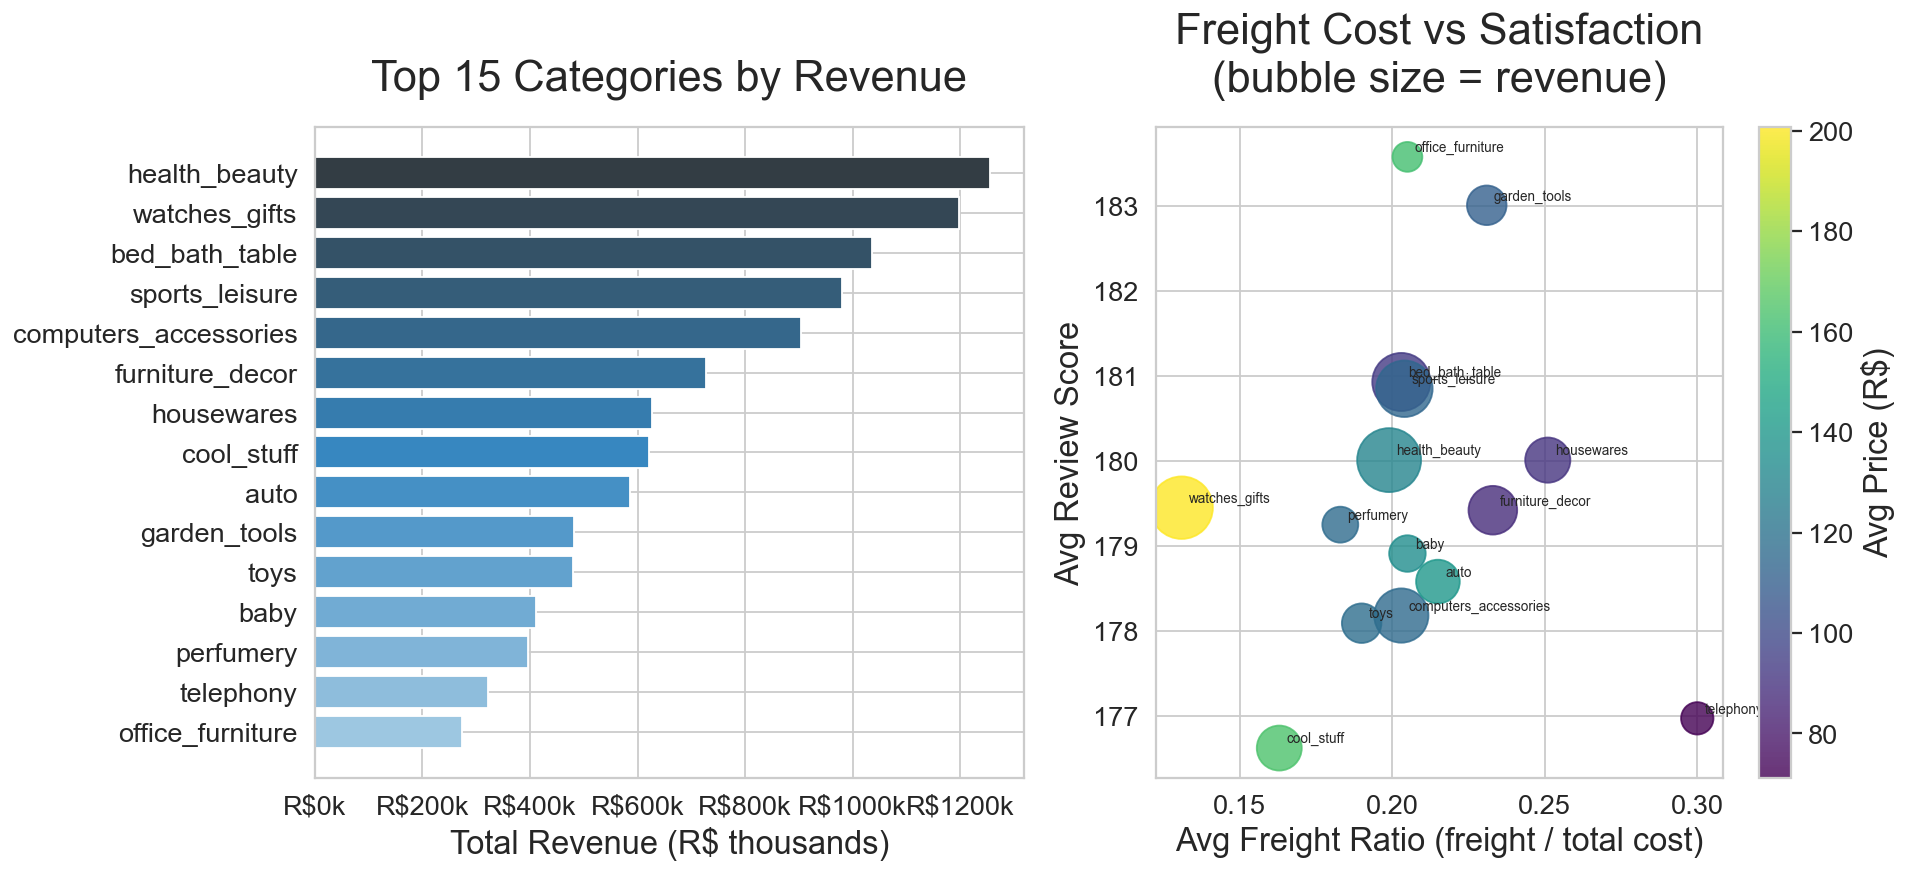

In [23]:
cats = q(f"""
    SELECT category, total_revenue, units_sold, avg_price,
           avg_freight_ratio, avg_review_score
    FROM `{BQ_PROJECT}.olist_marts.category_performance`
    ORDER BY total_revenue DESC LIMIT 15
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

bars = axes[0].barh(cats['category'][::-1], cats['total_revenue'][::-1] / 1e3,
                    color=sns.color_palette('Blues_d', 15))
axes[0].set_xlabel('Total Revenue (R$ thousands)')
axes[0].set_title('Top 15 Categories by Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}k'))

scatter = axes[1].scatter(
    cats['avg_freight_ratio'],
    cats['avg_review_score'],
    s=cats['total_revenue'] / 1000,
    c=cats['avg_price'],
    cmap='viridis',
    alpha=0.8
)
for _, row in cats.iterrows():
    axes[1].annotate(row['category'],
                     (row['avg_freight_ratio'], row['avg_review_score']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7.5)
plt.colorbar(scatter, ax=axes[1], label='Avg Price (R$)')
axes[1].set_xlabel('Avg Freight Ratio (freight / total cost)')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Freight Cost vs Satisfaction\n(bubble size = revenue)')

plt.tight_layout()
plt.savefig('../docs/category_performance.png', bbox_inches='tight')
plt.show()

---
## 5. Geographic Market Opportunity

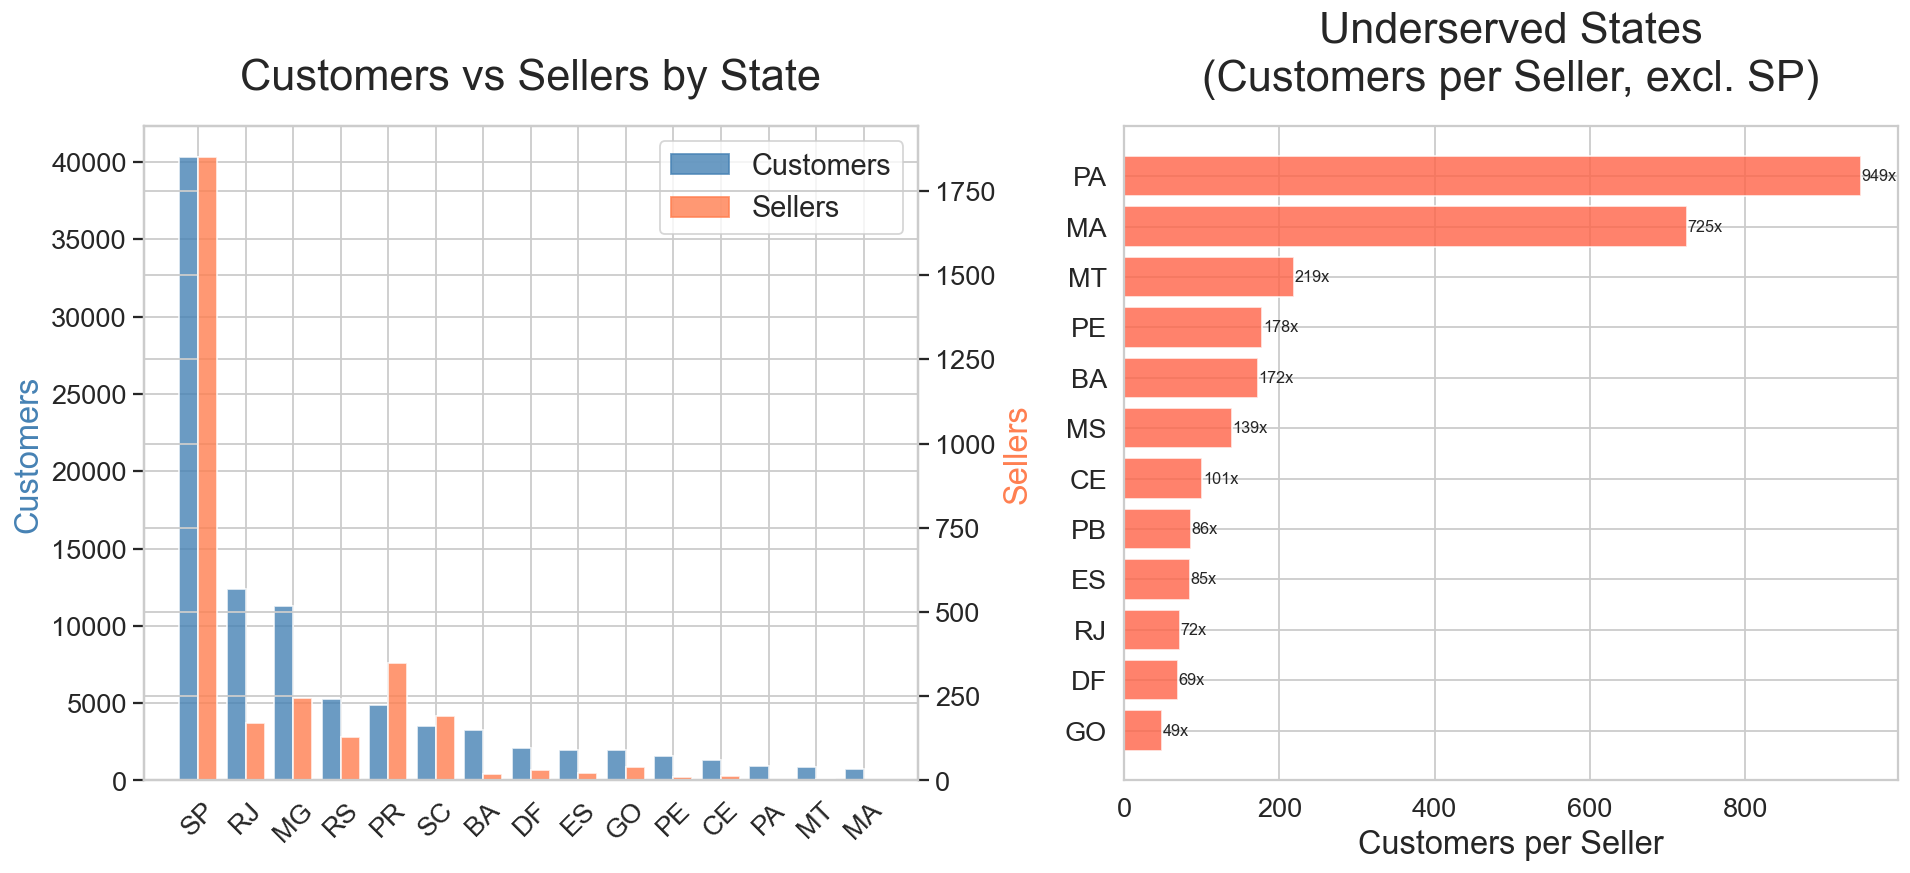

Top underserved states (customers/seller):
state  customers  sellers  customers_per_seller
   PA        949        1                 949.0
   MA        725        1                 725.0
   MT        875        4                 218.8
   PE       1604        9                 178.2
   BA       3276       19                 172.4
   MS        694        5                 138.8
   CE       1311       13                 100.8
   PB        519        6                  86.5
   ES       1964       23                  85.4
   RJ      12383      171                  72.4
   DF       2073       30                  69.1
   GO       1950       40                  48.8


In [24]:
geo = q(f"""
    WITH customer_state AS (
        SELECT state, COUNT(*) AS customers
        FROM `{BQ_PROJECT}.olist_warehouse.dim_customers`
        GROUP BY state
    ),
    seller_state AS (
        SELECT state, COUNT(*) AS sellers
        FROM `{BQ_PROJECT}.olist_warehouse.dim_sellers`
        GROUP BY state
    )
    SELECT
        c.state,
        c.customers,
        COALESCE(s.sellers, 0) AS sellers,
        ROUND(CAST(c.customers AS FLOAT64) / NULLIF(COALESCE(s.sellers, 0), 0), 1) AS customers_per_seller
    FROM customer_state c
    LEFT JOIN seller_state s USING (state)
    ORDER BY c.customers DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top15 = geo.head(15)
x = range(len(top15))
width = 0.4

ax2 = axes[0].twinx()
axes[0].bar([i - width/2 for i in x], top15['customers'], width, label='Customers', color='steelblue', alpha=0.8)
ax2.bar([i + width/2 for i in x], top15['sellers'], width, label='Sellers', color='coral', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(top15['state'], rotation=45)
axes[0].set_ylabel('Customers', color='steelblue')
ax2.set_ylabel('Sellers', color='coral')
axes[0].set_title('Customers vs Sellers by State')
p1 = mpatches.Patch(color='steelblue', alpha=0.8, label='Customers')
p2 = mpatches.Patch(color='coral',     alpha=0.8, label='Sellers')
axes[0].legend(handles=[p1, p2], loc='upper right')

underserved = geo[(geo['state'] != 'SP') & (geo['customers'] >= 500)].sort_values('customers_per_seller', ascending=False).head(12)
axes[1].barh(underserved['state'][::-1], underserved['customers_per_seller'][::-1], color='tomato', alpha=0.8)
axes[1].set_xlabel('Customers per Seller')
axes[1].set_title('Underserved States\n(Customers per Seller, excl. SP)')
for i, (val, state) in enumerate(zip(underserved['customers_per_seller'][::-1], underserved['state'][::-1])):
    axes[1].text(val + 0.5, i, f'{val:.0f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/geo_opportunity.png', bbox_inches='tight')
plt.show()

print("Top underserved states (customers/seller):")
print(underserved[['state','customers','sellers','customers_per_seller']].to_string(index=False))

---
## 6. Executive Summary

In [25]:
summary = q(f"""
    SELECT
        COUNT(DISTINCT order_id)                             AS total_orders,
        COUNT(DISTINCT customer_key)                         AS unique_customers,
        ROUND(SUM(total_payment), 0)                         AS total_revenue,
        ROUND(AVG(total_payment), 2)                         AS avg_order_value,
        ROUND(AVG(avg_review_score), 2)                      AS avg_review_score,
        ROUND(AVG(CASE WHEN delivery_delay_days IS NOT NULL
                       THEN delivery_delay_days END), 2)     AS avg_delivery_delay,
        SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) AS late_orders
    FROM `{BQ_PROJECT}.olist_warehouse.fact_orders`
    WHERE order_status NOT IN ('canceled','unavailable')
""")

rfm_seg = q(f"""
    SELECT segment, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM `{BQ_PROJECT}.olist_marts.customer_rfm`
    GROUP BY segment ORDER BY n DESC
""")

print("=" * 55)
print("  OLIST EXECUTIVE SUMMARY")
print("=" * 55)
r = summary.iloc[0]
print(f"  Period:              Sep 2016 - Oct 2018")
print(f"  Total Orders:        {int(r.total_orders):,}")
print(f"  Unique Customers:    {int(r.unique_customers):,}")
print(f"  Total Revenue:       R${int(r.total_revenue):,}")
print(f"  Avg Order Value:     R${r.avg_order_value}")
print(f"  Avg Review Score:    {r.avg_review_score} / 5.0")
print(f"  Avg Delivery Delay:  {r.avg_delivery_delay} days (neg = early)")
print(f"  Late Deliveries:     {int(r.late_orders):,}")
print()
print("  CUSTOMER SEGMENTS:")
for _, row in rfm_seg.iterrows():
    print(f"  {row.segment:<18} {int(row.n):>7,}  ({row.pct}%)")
print("=" * 55)

print("""
KEY INSIGHTS:
1. 96.9% of customers never return -- fixing retention is the #1 lever
2. Delivery communication gap: even orders arriving 4 days early get 1-star reviews
   -- customers' expectations are set too optimistically
3. Non-SP states face 2-5x higher freight ratios with fewer local sellers
   -- expanding the seller base outside SP could unlock significant revenue
4. Health & Beauty, Watches, Bed/Bath are top revenue categories -- all amenable
   to subscription/repeat purchase models if retention is addressed
""")

  OLIST EXECUTIVE SUMMARY
  Period:              Sep 2016 - Oct 2018
  Total Orders:        98,207
  Unique Customers:    94,990
  Total Revenue:       R$15,739,137
  Avg Order Value:     R$160.26
  Avg Review Score:    4.120000000 / 5.0
  Avg Delivery Delay:  -11.88 days (neg = early)
  Late Deliveries:     6,534

  CUSTOMER SEGMENTS:
  At Risk             24,330  (25.6%)
  Needs Attention     23,485  (24.7%)
  Champion            17,034  (17.9%)
  Loyal               15,630  (16.5%)
  Promising           10,960  (11.5%)
  Cant Lose            3,303  (3.5%)
  Lost                   248  (0.3%)

KEY INSIGHTS:
1. 96.9% of customers never return -- fixing retention is the #1 lever
2. Delivery communication gap: even orders arriving 4 days early get 1-star reviews
   -- customers' expectations are set too optimistically
3. Non-SP states face 2-5x higher freight ratios with fewer local sellers
   -- expanding the seller base outside SP could unlock significant revenue
4. Health & Beauty, W

---
## 9. Risk Register

Four key business risks identified from the data, scored by **Likelihood × Impact** (each rated Low/Medium/High = 1/2/3).

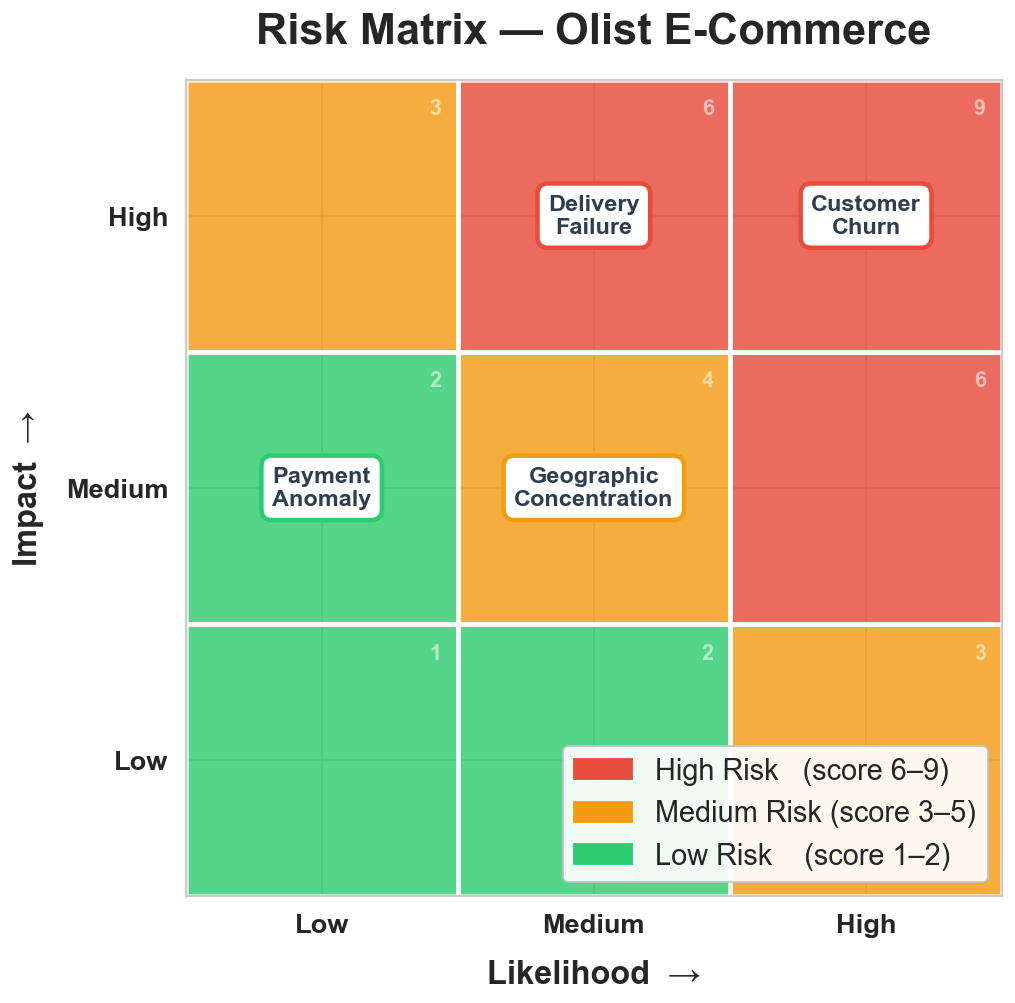

RISK REGISTER SUMMARY
----------------------------------------------------------
Risk                       Likelihood   Impact     Score   Level
----------------------------------------------------------
Customer Churn             High         High       9       HIGH
Delivery Failure           Medium       High       6       HIGH
Geographic Concentration   Medium       Medium     4       MEDIUM
Payment Anomaly            Low          Medium     2       LOW


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

risks = [
    {'name': 'Customer\nChurn',          'likelihood': 3, 'impact': 3},
    {'name': 'Delivery\nFailure',        'likelihood': 2, 'impact': 3},
    {'name': 'Geographic\nConcentration','likelihood': 2, 'impact': 2},
    {'name': 'Payment\nAnomaly',         'likelihood': 1, 'impact': 2},
]

cell_colors = {
    (1,1):'#2ecc71', (1,2):'#2ecc71', (1,3):'#f39c12',
    (2,1):'#2ecc71', (2,2):'#f39c12', (2,3):'#e74c3c',
    (3,1):'#f39c12', (3,2):'#e74c3c', (3,3):'#e74c3c',
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')

for (impact, likelihood), color in cell_colors.items():
    rect = mpatches.FancyBboxPatch(
        (likelihood - 1, impact - 1), 1, 1,
        boxstyle='square,pad=0',
        facecolor=color, edgecolor='white', linewidth=2.5, alpha=0.82
    )
    ax.add_patch(rect)
    score = likelihood * impact
    ax.text(likelihood - 0.06, impact - 0.07, str(score),
            fontsize=12, color='white', alpha=0.55,
            ha='right', va='top', fontweight='bold')

for r in risks:
    lx = r['likelihood'] - 0.5
    iy = r['impact'] - 0.5
    score = r['likelihood'] * r['impact']
    border = '#e74c3c' if score >= 6 else ('#f39c12' if score >= 3 else '#2ecc71')
    ax.text(lx, iy, r['name'],
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
                      edgecolor=border, linewidth=2.5))

for i in range(1, 3):
    ax.axhline(i, color='white', linewidth=2.5)
    ax.axvline(i, color='white', linewidth=2.5)

ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=15, fontweight='bold')
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=15, fontweight='bold')
ax.set_xlabel('Likelihood  →', fontweight='bold', labelpad=12)
ax.set_ylabel('Impact  →',     fontweight='bold', labelpad=12)
ax.set_title('Risk Matrix — Olist E-Commerce', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High Risk   (score 6–9)'),
    mpatches.Patch(color='#f39c12', label='Medium Risk (score 3–5)'),
    mpatches.Patch(color='#2ecc71', label='Low Risk    (score 1–2)'),
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.92, edgecolor='#bdc3c7')

plt.tight_layout()
plt.savefig('../docs/risk_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print("RISK REGISTER SUMMARY")
print("-" * 58)
print(f"{'Risk':<26} {'Likelihood':<12} {'Impact':<10} {'Score':<7} Level")
print("-" * 58)
lvl = {1: 'Low', 2: 'Medium', 3: 'High'}
for r in risks:
    score = r['likelihood'] * r['impact']
    level = 'HIGH' if score >= 6 else ('MEDIUM' if score >= 3 else 'LOW')
    name  = r['name'].replace('\n', ' ')
    print(f"{name:<26} {lvl[r['likelihood']]:<12} {lvl[r['impact']]:<10} {score:<7} {level}")

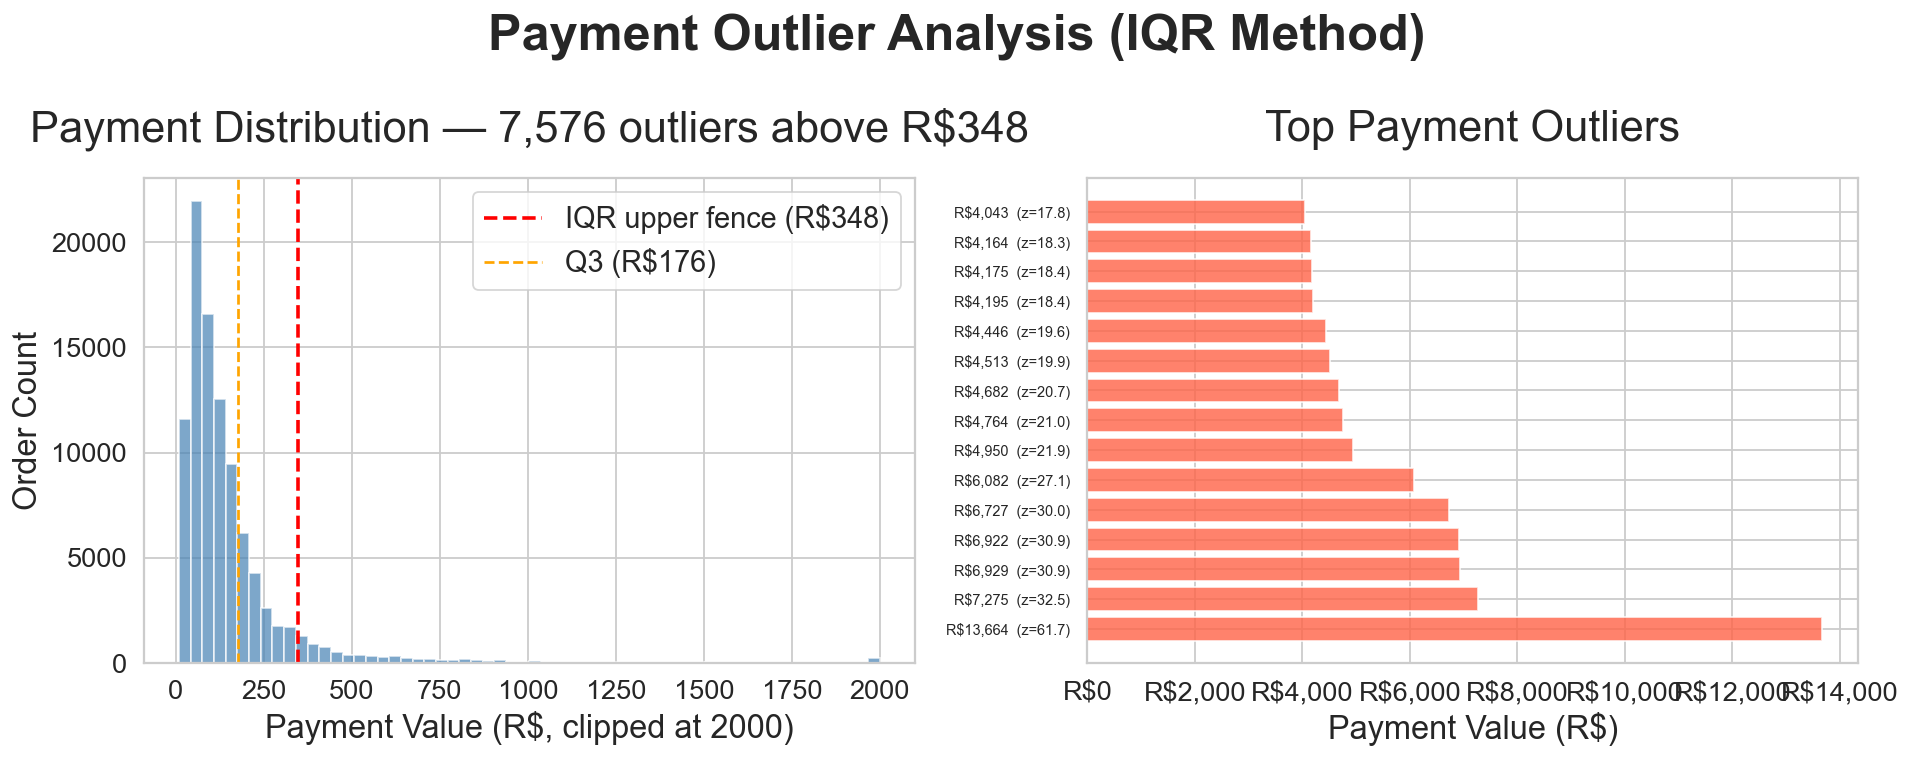

Payment IQR bounds:  Q1=R$61.88  Q3=R$176.33  IQR=R$114.45
Fences:  lower=R$-109.80  upper=R$348.01
High-value outliers: 7,576
Low-value outliers:  0

Delivery delay fences:  lower=-32d  upper=8d
Extreme late (>8d):  2,526 orders  |  avg review: 1.70/5
Extreme early (<-32d): 1,771 orders  |  avg review: 4.26/5


In [27]:
pay_out = q(f"SELECT * FROM `{BQ_PROJECT}.olist_marts.payment_outliers` ORDER BY total_payment DESC")
del_out = q(f"SELECT * FROM `{BQ_PROJECT}.olist_marts.delivery_outliers` ORDER BY delivery_delay_days DESC")

q1  = pay_out.iloc[0]['q1']
q3  = pay_out.iloc[0]['q3']
iqr = pay_out.iloc[0]['iqr']
lower_fence = pay_out.iloc[0]['lower_fence']
upper_fence = pay_out.iloc[0]['upper_fence']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

all_pay = q(f"""
    SELECT total_payment FROM `{BQ_PROJECT}.olist_warehouse.fact_orders`
    WHERE order_status = 'delivered' AND total_payment > 0
""")
axes[0].hist(all_pay['total_payment'].clip(upper=2000), bins=60, color='steelblue', alpha=0.7)
axes[0].axvline(upper_fence, color='red', linestyle='--', linewidth=2,
                label=f'IQR upper fence (R${upper_fence:.0f})')
axes[0].axvline(q3, color='orange', linestyle='--', linewidth=1.5,
                label=f'Q3 (R${q3:.0f})')
axes[0].set_xlabel('Payment Value (R$, clipped at 2000)')
axes[0].set_ylabel('Order Count')
axes[0].set_title(f'Payment Distribution — {len(pay_out):,} outliers above R${upper_fence:.0f}')
axes[0].legend()

top_out = pay_out.head(15).reset_index(drop=True)
axes[1].barh(range(len(top_out)), top_out['total_payment'], color='tomato', alpha=0.8)
axes[1].set_yticks(range(len(top_out)))
axes[1].set_yticklabels([f"R${v:,.0f}  (z={z:.1f})" for v, z in
                          zip(top_out['total_payment'], top_out['z_score'])], fontsize=8)
axes[1].set_xlabel('Payment Value (R$)')
axes[1].set_title('Top Payment Outliers')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.suptitle('Payment Outlier Analysis (IQR Method)', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/payment_outliers.png', bbox_inches='tight')
plt.show()

print(f"Payment IQR bounds:  Q1=R${q1:,.2f}  Q3=R${q3:,.2f}  IQR=R${iqr:,.2f}")
print(f"Fences:  lower=R${lower_fence:,.2f}  upper=R${upper_fence:,.2f}")
print(f"High-value outliers: {len(pay_out[pay_out.outlier_flag == 'high_outlier']):,}")
print(f"Low-value outliers:  {len(pay_out[pay_out.outlier_flag == 'low_outlier']):,}")
print()
if len(del_out) > 0:
    extreme_late  = del_out[del_out.outlier_flag == 'extreme_late']
    extreme_early = del_out[del_out.outlier_flag == 'extreme_early']
    print(f"Delivery delay fences:  lower={del_out.lower_fence.iloc[0]:.0f}d  upper={del_out.upper_fence.iloc[0]:.0f}d")
    print(f"Extreme late (>{del_out.upper_fence.iloc[0]:.0f}d):  {len(extreme_late):,} orders  |  avg review: {extreme_late['avg_review_score'].mean():.2f}/5")
    print(f"Extreme early (<{del_out.lower_fence.iloc[0]:.0f}d): {len(extreme_early):,} orders  |  avg review: {extreme_early['avg_review_score'].mean():.2f}/5")

---
## 8. Outlier Analysis

Payment values and delivery delays are assessed using the **IQR (Interquartile Range)** method.  
Outlier fence = Q1 - 1.5×IQR (lower) and Q3 + 1.5×IQR (upper).  
Z-scores are also computed to quantify how extreme each outlier is.

=== DATA QUALITY REPORT ===

Table: fact_orders
  Total rows:              99,441
  Excluded (status):        1,234  (1.2%)
  Zero payment/price:           4
  Missing review:             768
  Missing delay data:       2,965
  Clean delivered:         96,478  (97.0%)

Table: fact_order_items
  Total rows:             112,650
  Excluded (status):          549  (0.5%)
  Zero payment/price:           0
  Clean delivered:        110,197  (97.8%)



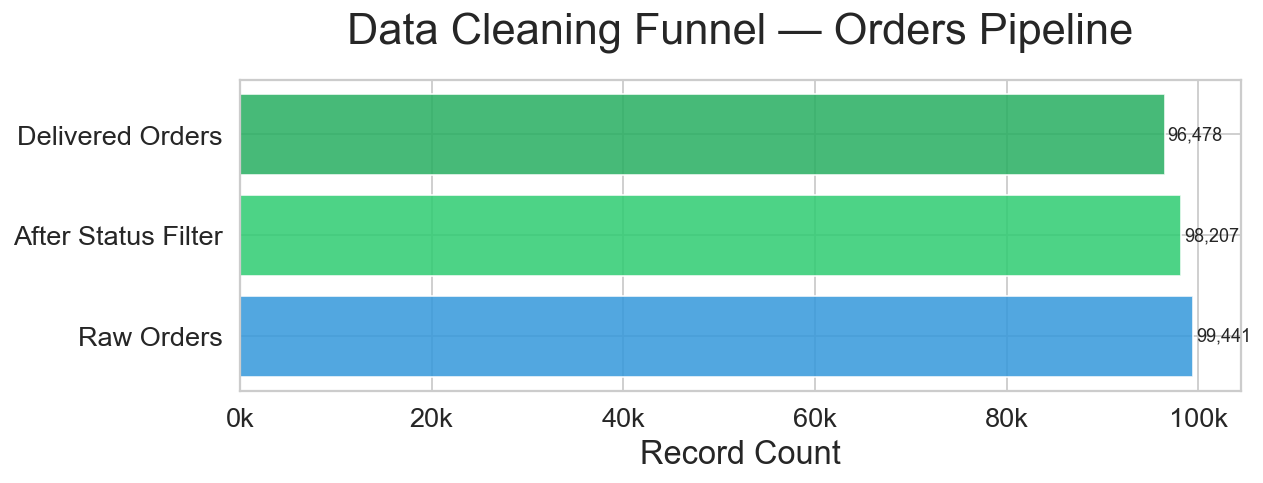

In [28]:
dq = q(f"SELECT * FROM `{BQ_PROJECT}.olist_marts.data_quality`")

print("=== DATA QUALITY REPORT ===\n")
for _, row in dq.iterrows():
    pct_clean = 100 * row.clean_delivered / row.total_rows
    pct_excluded = 100 * row.excluded_status / row.total_rows
    print(f"Table: {row.table_name}")
    print(f"  Total rows:          {int(row.total_rows):>10,}")
    print(f"  Excluded (status):   {int(row.excluded_status):>10,}  ({pct_excluded:.1f}%)")
    print(f"  Zero payment/price:  {int(row.zero_payment):>10,}")
    if row.missing_review > 0:
        print(f"  Missing review:      {int(row.missing_review):>10,}")
    if row.missing_delay > 0:
        print(f"  Missing delay data:  {int(row.missing_delay):>10,}")
    print(f"  Clean delivered:     {int(row.clean_delivered):>10,}  ({pct_clean:.1f}%)")
    print()

# Cleaning funnel chart
orders_row = dq[dq.table_name == 'fact_orders'].iloc[0]
labels = ['Raw Orders', 'After Status Filter', 'Delivered Orders']
counts = [
    int(orders_row.total_rows),
    int(orders_row.total_rows) - int(orders_row.excluded_status),
    int(orders_row.clean_delivered),
]
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#3498db', '#2ecc71', '#27ae60']
bars = ax.barh(labels, counts, color=colors, alpha=0.85)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=10)
ax.set_xlabel('Record Count')
ax.set_title('Data Cleaning Funnel — Orders Pipeline')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('../docs/data_cleaning_funnel.png', bbox_inches='tight')
plt.show()

---
## 7. Data Cleaning Report

The pipeline applies the following cleaning rules before building the warehouse:

| Issue | Rule | Action |
|-------|------|--------|
| Cancelled / unavailable orders | `order_status IN ('canceled','unavailable')` | Excluded from all marts |
| Zero-value payments | `total_payment = 0` | Flagged; excluded from payment analysis |
| Missing review scores | `avg_review_score IS NULL` | Retained; excluded from satisfaction analysis |
| Missing delivery timestamps | `delivered_at IS NULL AND status = 'delivered'` | Flagged; excluded from delay calculations |
| Missing delivery delay | `delivery_delay_days IS NULL` | Excluded from delay/risk analysis |